In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import ast
from scipy import stats
import librosa
import warnings

In [2]:
print(os.getcwd())
paths = {}
for root, dirs, files in os.walk(os.path.join(os.getcwd(), "fma_small")):
    if root.endswith("fma_small"):
        continue
    for file in files:
        full_path = os.path.join(root, file)
        track_id = int(file.split(".")[0])
        paths[track_id] = full_path

/home/jakub-karczewski/Dokumenty/data_exploration_project


In [3]:
paths
len(list(paths.keys()))

8000

In [4]:
def columns():
    feature_sizes = dict(
        chroma_stft=12,
        mfcc=20, rms=1, zcr=1,
        spectral_centroid=1
    )
    moments = ('mean', 'std')

    tuples = [
        (feature, moment, f"{i+1:02d}")
        for feature, size in feature_sizes.items()
        for moment in moments
        for i in range(size)
    ]

    return pd.MultiIndex.from_tuples(tuples, names=('feature', 'statistics', 'number')).sort_values()

In [5]:
import librosa
import numpy as np
import pandas as pd
import torch

from panns_inference import AudioTagging

device = 'cuda' if torch.cuda.is_available() else 'cpu'

audio_tagging = AudioTagging(
    checkpoint_path=None,
    device=device
)

EMBEDDING_SIZE = 2048


def compute_panns_features(tid):
    filepath = paths[tid]

    try:
        audio, sr = librosa.load(
            filepath,
            sr=32000,
            mono=True,
            dtype=np.float32
        )

        audio = audio[None, :]

        with torch.no_grad():
            clipwise_output, embedding = audio_tagging.inference(audio)

        if torch.is_tensor(embedding):
            embedding = embedding.cpu().numpy()

        embedding = embedding.squeeze()

        return pd.Series(embedding, name=tid)

    except Exception as e:
        print(f"Error processing {tid}: {e}")

        return pd.Series(
            np.zeros(EMBEDDING_SIZE, dtype=np.float32),
            name=tid
        )

Checkpoint path: /home/jakub-karczewski/panns_data/Cnn14_mAP=0.431.pth


/home/jakub-karczewski/Dokumenty/data_exploration_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU number: 1


In [6]:
track_ids = list(paths.keys())

features = pd.DataFrame(
    index=track_ids,
    columns=columns(),
    dtype=np.float32
)

### To be used on Linux

In [ ]:
from joblib import Parallel, delayed

results = []

for i, tid in enumerate(track_ids):
    if i % 500 == 0:
        print(i, end = ' ')
    results.append(compute_panns_features(tid))

X = pd.DataFrame(results)

0 500 1000 

[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!


1500 

In [14]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
120161,0.0,0.000000,0.0,0.0,0.0,0.065903,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.041369,0.000000,0.778215,0.0
120325,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.944425,0.000000,0.174031,0.0
120315,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.330279,0.059467,0.000798,0.0
120504,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.328960,0.069268,0.000000,0.0
120312,0.0,0.270404,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.789381,0.000000,0.486817,0.0


In [15]:
X.isna().sum().sum()

np.int64(0)

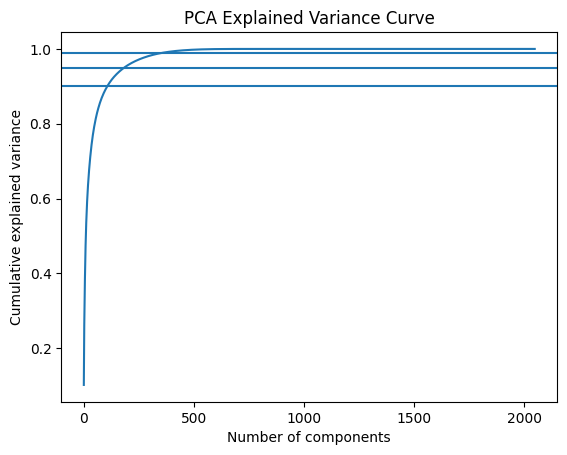

In [ ]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

X_norm = pd.DataFrame(
    normalize(X.values, norm = "l2"),
    index=X.index
)
pca = PCA().fit(X_norm)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure()
plt.plot(cumulative)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance Curve")
plt.axhline(0.90)
plt.axhline(0.95)
plt.axhline(0.99)
plt.show()


def pick_components(cumvar, target=0.95):
    return np.argmax(cumvar >= target) + 1

In [ ]:
def pick_components(cumvar, target=0.95):
    return np.argmax(cumvar >= target) + 1

n_95 = pick_components(cumulative, 0.95)
n_90 = pick_components(cumulative, 0.90)

print(n_95, n_90)

185 108


In [28]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(X.iloc[[0]], X)
top_k = sim[0].argsort()[-10:][::-1]

print(top_k)

[   0 1617 7862 6526 4358 4348 2186 6277 2684 1411]


In [ ]:
pca_185 = PCA(n_components=185, random_state=0)
X_feat = pca.fit_transform(X_norm)